### Import packages

In [315]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [316]:
df = pd.read_csv("student_exam_scores.csv")

In [317]:
df.head(5)

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [318]:
df.isna().sum()

student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

In [319]:
df.duplicated().sum()

np.int64(0)

In [320]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    str    
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), str(1)
memory usage: 9.5 KB


In [321]:
df.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [322]:
df.shape

(200, 6)

In [323]:
df.drop(columns=['student_id'], inplace=True)
df

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,8.0,8.8,72.1,45,30.2
1,1.3,8.6,60.7,55,25.0
2,4.0,8.2,73.7,86,35.8
3,3.5,4.8,95.1,66,34.0
4,9.1,6.4,89.8,71,40.3
...,...,...,...,...,...
195,10.5,5.4,94.0,87,42.7
196,7.1,6.1,85.1,92,40.4
197,1.6,6.9,63.8,76,28.2
198,12.0,7.3,50.5,58,42.0


In [324]:
df.shape

(200, 5)

In [325]:
x = df.drop(columns=['exam_score'])
y = df['exam_score']

In [326]:
x

,hours_studied,sleep_hours,attendance_percent,previous_scores
0,8.0,8.8,72.1,45
1,1.3,8.6,60.7,55
2,4.0,8.2,73.7,86
3,3.5,4.8,95.1,66
4,9.1,6.4,89.8,71
...,...,...,...,...
195,10.5,5.4,94.0,87
196,7.1,6.1,85.1,92
197,1.6,6.9,63.8,76
198,12.0,7.3,50.5,58


In [327]:
y

0      30.2
1      25.0
2      35.8
3      34.0
4      40.3
       ... 
195    42.7
196    40.4
197    28.2
198    42.0
199    37.8
Name: exam_score, Length: 200, dtype: float64

In [328]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

In [329]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((160, 4), (40, 4), (160,), (40,))

In [330]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

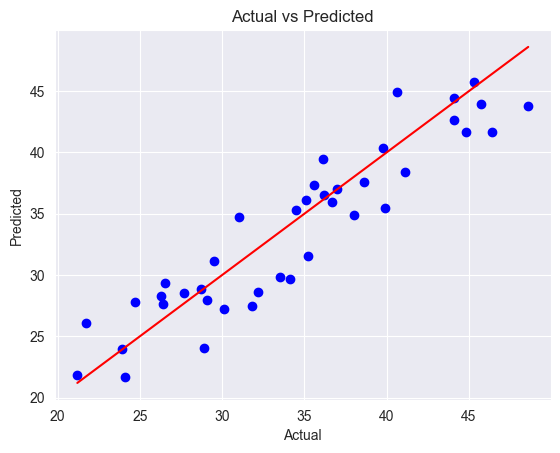

In [331]:

plt.scatter(y_test, y_pred, color='blue')

# Ideal line (perfect predictions)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

### Lasso Model

In [332]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.1,max_iter=100,tol=0.1)
lasso_model.fit(x_train,y_train)



,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",100
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.1
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


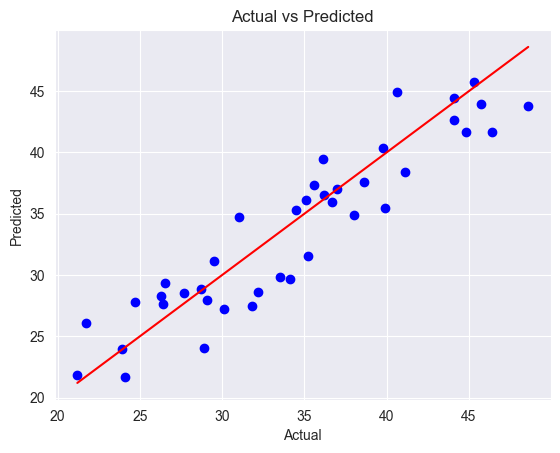

In [333]:
lasso_pred = lasso_model.predict(x_test)

plt.scatter(y_test, y_pred, color='blue')

# Ideal line (perfect predictions)
min_val = min(y_test.min(), lasso_pred.min())
max_val = max(y_test.max(), lasso_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

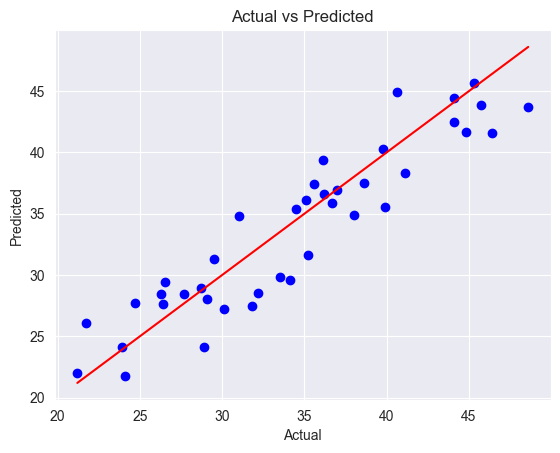

In [334]:
from sklearn.linear_model import Ridge
Ridge_model = Ridge(alpha=0.1,max_iter=100,tol=0.1)
Ridge_model.fit(x_train,y_train)
Ridge_pred = Ridge_model.predict(x_test)
Ridge_pred = lasso_model.predict(x_test)

plt.scatter(y_test, Ridge_pred, color='blue')

# Ideal line (perfect predictions)
min_val = min(y_test.min(), Ridge_pred.min())
max_val = max(y_test.max(), Ridge_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [335]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("Linear Regression")
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))


print("Lasso model")
print("MAE",mean_absolute_error(y_test,lasso_pred))
print("MSE",mean_squared_error(y_test,lasso_pred))
print("R2 score",r2_score(y_test,lasso_pred))
print("Ridge  model")
print("MAE",mean_absolute_error(y_test,Ridge_pred))
print("MSE",mean_squared_error(y_test,Ridge_pred))
print("R2 score",r2_score(y_test,Ridge_pred))



Linear Regression
MAE 2.3108582358958336
MSE 7.761782668623073
R2 score 0.8537447137159517
Lasso model
MAE 2.335767464997084
MSE 7.841123022619959
R2 score 0.8522497032675658
Ridge  model
MAE 2.335767464997084
MSE 7.841123022619959
R2 score 0.8522497032675658
